In [19]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def load_img(path, filename):
  os.chdir(path)
  src_img = cv2.imread(filename)
  src_img = cv2.resize(src_img, (45, 45))
  src_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY)
  return src_img

def load_imgs(path, filenames):
  return [load_img(path, filename) for filename in filenames]

In [4]:
src_img = load_img("/home/kuliaev_s/Space/Institute/МФТИ/Python/Dev/Semester_10/hw_4/data/source", "image.png")

In [5]:
filenames = ["res_0.png", "res_1.png", "res_2.png", "res_3.png"]
gen_imgs = load_imgs("/home/kuliaev_s/Space/Institute/МФТИ/Python/Dev/Semester_10/hw_4/data/generated", filenames)

In [6]:
def show(imgs):
  for img in imgs:
    plt.figure()
    plt.imshow(img, cmap='gray')

In [34]:
def get_wb_map(img):
  norm_img = img / 255.0
  
  for row in range(0, norm_img.shape[0]):
    for col in range(0, norm_img.shape[1]):
      if norm_img[row, col] > 0.65:
        norm_img[row, col] = 0
      else:
        norm_img[row, col] = 1

  return norm_img

def get_wb_maps(imgs):
  return [get_wb_map(img) for img in imgs]

In [35]:
wb_src_img = get_wb_map(src_img)

In [36]:
wb_gen_imgs = get_wb_maps(gen_imgs)

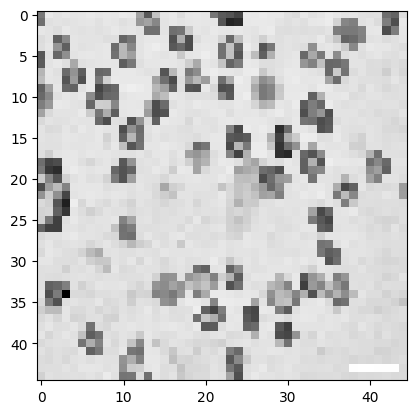

In [37]:
show([src_img])

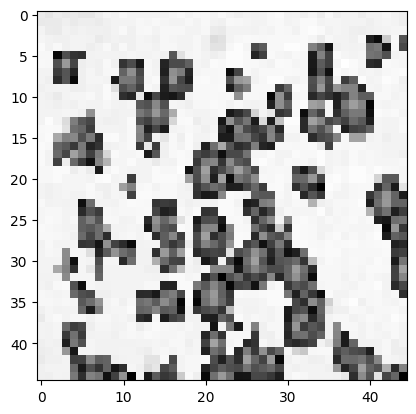

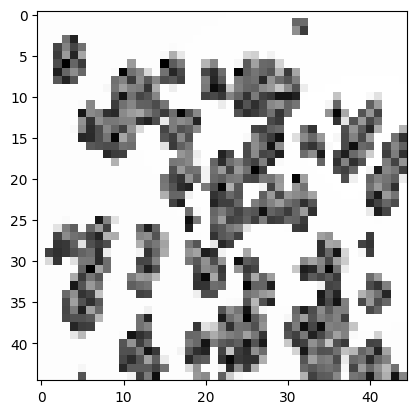

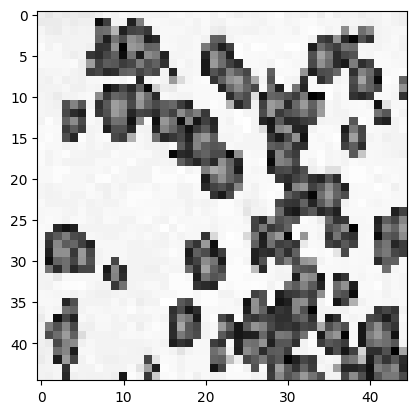

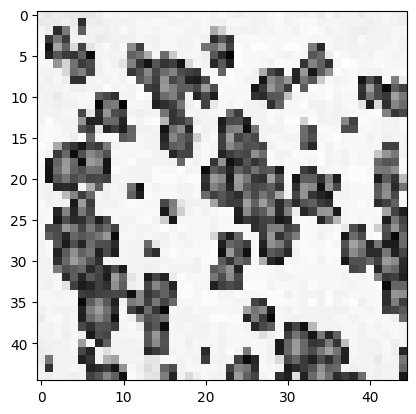

In [38]:
show(gen_imgs)

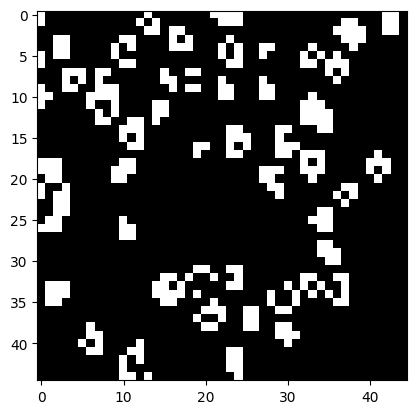

In [62]:
show([wb_src_img])

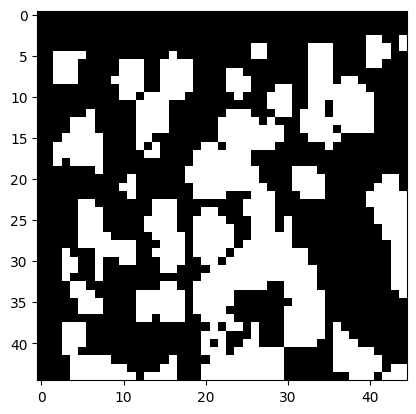

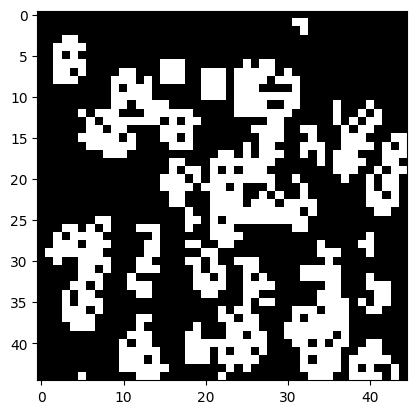

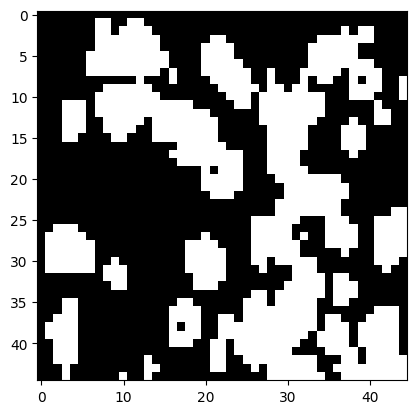

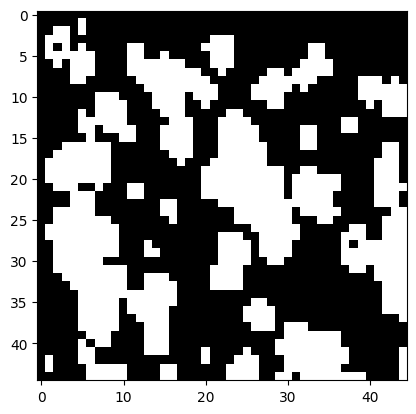

In [63]:
show(wb_gen_imgs)

In [15]:
def get_cell_pixs_coords(img):
  return [(row, col) for row in range(0, img.shape[0]) for col in range(0, img.shape[1]) if img[row, col] == 0]

In [16]:
def get_cell_pixs_coords_for_list(imgs):
  return [get_cell_pixs_coords(img) for img in imgs]

In [17]:
def get_cell_pixs_dist(coords):
  return [(((0 - elem[0])**2 + (0 - elem[1])**2)**(1/2)) for elem in coords]

In [18]:
def get_cell_pixs_dist_for_list(coordss):
  return [get_cell_pixs_dist(coords) for coords in coordss]

In [70]:
import time
from abc import ABC, abstractmethod

In [ ]:
class TemplateMatcher(ABC):
  def __init__(self, image, templates):
    self.image = image
    self.templates = templates
    self.best_template = None
    self.best_mse = float('inf')
  
  @abstractmethod
  def find_best_template(self):
    pass
  
  def mse(self, img1, img2):
    return np.mean((img1 - img2)**2)
  
class PeanoGSOptimizer(TemplateMatcher):
  def __init__(self, image, templates, levels=3):
    super().__init__(image, templates)
    self.levels = levels
  
  def peano_sequence(self, size, level):
    if level == 0:
      return [(0, 0)]
    seq = []
    subsize = size // 3
    for i in [0, 1, 2]:
      for j in [0, 1, 2]:
        x, y = i*subsize, j*subsize
        subseq = self.peano_sequence(subsize, level-1)
        seq += [(x + px, y + py) for px, py in subseq]
    return seq
  
  def find_best_template(self):
    start_time = time.time()
    size = 9
    search_seq = self.peano_sequence(size, self.levels)
    
    for template in self.templates:
      current_mse = self.mse(self.image, template)
      if current_mse < self.best_mse:
        self.best_mse = current_mse
        self.best_template = template
     
    exec_time = time.time() - start_time
    return self.best_template, self.best_mse, exec_time

class MonteCarloGDOptimizer(TemplateMatcher):
  def __init__(self, image, templates, num_samples=100, top_k=5, lr=0.1, iterations=50):
    super().__init__(image, templates)
    self.num_samples = num_samples
    self.top_k = top_k
    self.lr = lr
    self.iterations = iterations
  
  def gradient(self, template):
    grad = np.zeros_like(template)
    h, w = template.shape
    for i in range(h):
      for j in range(w):
        temp_plus = template.copy()
        temp_minus = template.copy()
        temp_plus[i,j] += 1e-3
        temp_minus[i,j] -= 1e-3
        grad[i,j] = (self.mse(self.image, temp_plus) - self.mse(self.image, temp_minus)) / 2e-3
    return grad
    
  def find_best_template(self):
    start_time = time.time()
    
    mse_values = [self.mse(self.image, t) for t in self.templates]
    best_templates = [self.templates[i] for i in np.argsort(mse_values)[:self.top_k]]
    
    for template in best_templates:
      for _ in range(self.iterations):
        grad = self.gradient(template)
        template = np.clip(template - self.lr * grad, 0, 1)
        current_mse = self.mse(self.image, template)
        if current_mse < self.best_mse:
          self.best_mse = current_mse
          self.best_template = template
                    
    exec_time = time.time() - start_time
    return self.best_template, self.best_mse, exec_time

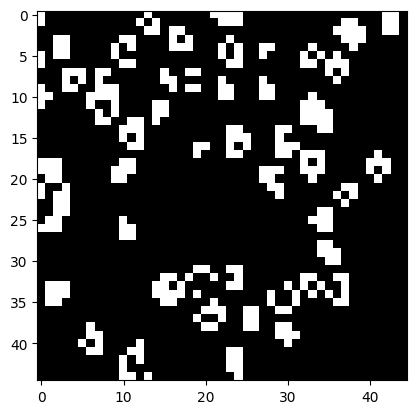

In [86]:
show([wb_src_img])

Peano+GSO:
Best MSE: 0.3960, Time: 0.00s
Best template:
 None

MonteCarlo+GD:
Best MSE: 0.3922, Time: 5.28s
Best template:
 None


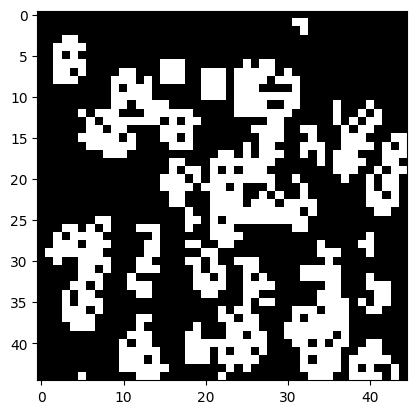

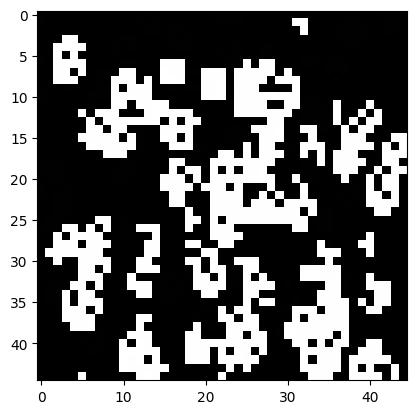

In [ ]:
peano_matcher = PeanoGSOptimizer(wb_src_img, wb_gen_imgs, levels=3)
mc_matcher = MonteCarloGDOptimizer(wb_src_img, wb_gen_imgs, num_samples=100)
    
# Запуск оптимизации
peano_result = peano_matcher.find_best_template()
mc_result = mc_matcher.find_best_template()

print("Peano+GSO:")
print(f"Best MSE: {peano_result[1]:.4f}, Time: {peano_result[2]:.2f}s")
print("Best template:\n", show([peano_result[0]]))

print("\nMonteCarlo+GD:")
print(f"Best MSE: {mc_result[1]:.4f}, Time: {mc_result[2]:.2f}s")
print("Best template:\n", show([mc_result[0]]))